# 3. Trenowanie i porównanie modeli

---

## Zadania

Implementacja i porównanie różnych podejść do rozpoznawania emocji w głosie (SER).

| # | Model | Wejście |
|---|-------|---------|
| 1 | **SVM** | Wektor 288 cech |
| 2 | **Sieć CNN** | Mel-spektrogram 128 x 94 |
| 3 | **HuBERT Base** | Waveform 16kHz, 3s |


## 1. Importy i konfiguracja

In [ ]:
import os
import time
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_recall_fscore_support
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Ścieżki
NOTEBOOK_DIR  = Path(os.getcwd())
ROOT_DIR      = NOTEBOOK_DIR.parent
PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
RESULTS_DIR   = ROOT_DIR / 'results' / '03_models_training'
MODELS_DIR    = ROOT_DIR / 'models'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Dane przetworzone: {PROCESSED_DIR}')
print(f'Modele:            {MODELS_DIR}')
print(f'Wyniki:            {RESULTS_DIR}')

Dane przetworzone: d:\zum\data\processed
Modele:            d:\zum\models
Wyniki:            d:\zum\results\03_models_training


## 2. Wczytanie danych

In [99]:
X_train_all = np.load(PROCESSED_DIR / 'X_ml_train.npy')
X_val = np.load(PROCESSED_DIR / 'X_ml_val.npy')

y_train_all = np.load(PROCESSED_DIR / 'y_train.npy')
y_val = np.load(PROCESSED_DIR / 'y_val.npy')

X_mel_train_np = np.load(PROCESSED_DIR / 'X_mel_train.npy')
X_mel_val_np = np.load(PROCESSED_DIR / 'X_mel_val.npy')

y_mel_train_np = np.load(PROCESSED_DIR / 'y_train_aug.npy')
y_mel_val_np = np.load(PROCESSED_DIR / 'y_val.npy')

metadata = pd.read_csv(PROCESSED_DIR / 'metadata.csv')
train_meta = metadata[metadata['split'] == 'train'].reset_index(drop=True)
val_meta = metadata[metadata['split'] == 'val'].reset_index(drop=True)
aug_meta = metadata[metadata['split'] == 'aug'].reset_index(drop=True)

with open(PROCESSED_DIR / 'label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

CLASS_NAMES = list(label_encoder.classes_)
N_CLASSES = len(CLASS_NAMES)

n_orig = len(train_meta)
n_aug = len(aug_meta)

# Podzbiór oryginalny - SVM nie korzysta z augmentacji
X_train = X_train_all[:n_orig]
y_train = y_train_all[:n_orig]

# Grupy aktorów dla StratifiedGroupKFold - wymagane by CV respektowało podział
actor_groups = train_meta['actor'].values

print('Rozmiary zbiorów:')
print(f'  train (oryginalne): X={X_train.shape}, y={y_train.shape}')
print(f'  pominięte augmentacje: {n_aug} próbek')
print(f'  val:   X={X_val.shape},  y={y_val.shape}')
print(f'\nKlasy ({N_CLASSES}): {CLASS_NAMES}')
print(f'Unikalni aktorzy w train: {len(np.unique(actor_groups))}')

Rozmiary zbiorów:
  train (oryginalne): X=(5862, 288), y=(5862,)
  pominięte augmentacje: 5862 próbek
  val:   X=(1318, 288),  y=(1318,)

Klasy (6): [np.str_('angry'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]
Unikalni aktorzy w train: 79


## 3. Klasyczny model ML - SVM

Dobór hiperparametrów odbywa się wg *macro F1*, aby lepiej traktować wszystkie klasy emocji.

Aby wyłonić najlepszy model porównano jądro liniowe oraz RBF.

StandardScaler normalizuje cechy numeryczne (ML features jak MFCC, pitch, energy itp.).
Scaler dopasowujemy tylko na danych treningowych, ponieważ obliczanie statystyk na zbiorach val i test dostarczałoby modelowi informacji o danych, których jeszcze nie widział, przez co sztucznie zawyżałoby wyniki i nie odzwierciedlałoby rzeczywistej skuteczności na nowych danych.
Skalowanie odbywa się w pipeline, dopiero na tym etapie, gdyż wcześniejsze jego wykonanie powoduje wyciek danych do CV.

### 3.1 Dobór modelu i hiperparametrów

In [ ]:
cv = StratifiedGroupKFold(n_splits=5)

#### 3.1.1 Model RBF

In [ ]:
pipe_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_SEED))
])

param_grid_rbf = {
    'clf__C': [0.1, 1, 10, 100, 1000],
    'clf__gamma': ['scale', 'auto', 1e-4, 1e-3, 1e-2, 1e-1],
}

gs_rbf = GridSearchCV(
    estimator = pipe_rbf,
    param_grid = param_grid_rbf,
    cv = cv,
    scoring = 'f1_macro',
    n_jobs = -1,
    verbose = 0,
)

print('GridSearch dla SVM RBF...')
t0 = time.time()
gs_rbf.fit(X_train, y_train, groups=actor_groups)
print(f'Czas: {time.time()-t0:.0f}s\nnajlepsze: {gs_rbf.best_params_}\nCV macro-F1: {gs_rbf.best_score_*100:.2f}%')

#### 3.1.2 Model Linear

In [ ]:
pipe_lin = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearSVC(class_weight='balanced', max_iter=15000, random_state=RANDOM_SEED))
])

param_grid_lin = {'clf__C': [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000]}

gs_lin = GridSearchCV(
    estimator = pipe_lin,
    param_grid = param_grid_lin,
    cv = cv,
    scoring = 'f1_macro',
    n_jobs = -1,
    verbose = 0,
)

print('GridSearch dla LinearSVC...')
t0 = time.time()
gs_lin.fit(X_train, y_train, groups=actor_groups)
print(f'Czas: {time.time()-t0:.0f}s\nnajlepsze: {gs_lin.best_params_}\nCV macro-F1: {gs_lin.best_score_*100:.2f}%')

#### 3.1.3 Heatmapa i wykres hiperparametrów 

In [ ]:
results_rbf = pd.DataFrame(gs_rbf.cv_results_)
pivot = results_rbf.pivot_table(
    index='param_clf__C', columns='param_clf__gamma', values='mean_test_score'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    pivot * 100, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=axes[0], cbar_kws={'label': 'CV Macro-F1 [%]'}
)
best_C = gs_rbf.best_params_['clf__C']
best_gamma = gs_rbf.best_params_['clf__gamma']
ri = list(pivot.index).index(best_C)
ci = list(pivot.columns).index(best_gamma)
axes[0].add_patch(plt.Rectangle((ci, ri), 1, 1, fill=False, edgecolor='blue', lw=3))
axes[0].set_title('GridSearch SVM RBF - CV Macro-F1 [%]', fontsize=12, fontweight='bold')
axes[0].set_xlabel('gamma')
axes[0].set_ylabel('C')

results_lin = pd.DataFrame(gs_lin.cv_results_)
axes[1].plot(results_lin['param_clf__C'], results_lin['mean_test_score'] * 100,
             'o-', color='#e74c3c', linewidth=2, markersize=8)
axes[1].axvline(gs_lin.best_params_['clf__C'], color='blue', linestyle='--', alpha=0.7,
                label=f'Najlepsze C={gs_lin.best_params_["clf__C"]}')
axes[1].set_xscale('log')
axes[1].set_xlabel('C')
axes[1].set_ylabel('CV Macro-F1 [%]')
axes[1].set_title('GridSearch LinearSVC - CV Macro-F1 [%]', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'svm_gridsearch_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'SVM RBF   - najlepsze CV macro-F1: {gs_rbf.best_score_*100:.2f}%  params={gs_rbf.best_params_}')
print(f'LinearSVC - najlepsze CV macro-F1: {gs_lin.best_score_*100:.2f}%  params={gs_lin.best_params_}')

### 3.2. Trening modelu finalnego

Wybieranu model jest już wytrenowany przez *GridSearchCV*, a *best_estimator_* daje nam do niego dostęp.  
Wybieramy model z wyższym CV *Macro-F1*.

In [ ]:
# Wybierz wariant z lepszym CV macro-F1
if gs_rbf.best_score_ >= gs_lin.best_score_:
    best_model = gs_rbf.best_estimator_
    selected_search = gs_rbf
    model_label = 'SVM RBF'
else:
    best_model = gs_lin.best_estimator_
    selected_search = gs_lin
    model_label = 'LinearSVC'

best_clf = best_model.named_steps['clf']
val_acc = selected_search.best_score_*100

print(f'Wybrany model: {model_label}')
print(f'  najlepsze: {selected_search.best_params_}')
print(f'  CV macro-F1: {selected_search.best_score_*100:.2f}%')
if hasattr(best_clf, 'n_support_'):
    print(f'  wektory nośne: {best_clf.n_support_.sum()}')


### 3.3. Zapis modelu

In [ ]:
model_path = MODELS_DIR / 'svm_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)
print(f'Model zapisany: {model_path.name}')

## 4. Sieć konwolucyjna CNN

CNN operuje bezpośrednio na 2D reprezentacji dźwięku (spektrogramy melowe 128 x 94).  
W przeciwieństwie do SVM, który używa zagregowanych statystyk (mean/std MFCC), CNN może wykrywać lokalne wzorce czasowo-częstotliwościowe charakterystyczne dla emocji.

**Dane wejściowe:** *X_mel_train/val.npy* - kształt (N, 128, 94)  
**Augmentacja:** CNN korzysta z pełnego *X_mel_train* (z augmentacją) - dla sieci głębokich augmentacja 2D jest wartościowa.

### 4.1 Instalacja pytorch GPU

Ponieważ trening CNN jest bardzo wymagający obliczeniowo. Wykorzystujemy pyTorch dla GPU jeżeli to tylko możliwe.

In [100]:
try:
    import torch
    print(f'GPU {"available" if torch.cuda.is_available() else "not available"}')
    print(f'pyTorch {torch.__version__}')
except ImportError:
    import subprocess, sys
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install',
        'torch', 'torchvision',
        '--index-url', 'https://download.pytorch.org/whl/cpu',
        '-q'
    ])
    import torch
    print(f'PyTorch {torch.__version__} zainstalowany.')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Używane urządzenie: {DEVICE}')

GPU available
pyTorch 2.5.1+cu121
Używane urządzenie: cuda


In [101]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import itertools
import random

### 4.1 Przygotowanie mel-spektrogramów

In [102]:
# Dodanie wymiaru kanału (mono): (N, 128, 94) w (N, 1, 128, 94)
def to_tensor_dataset(X, y):
    X_t = torch.tensor(X[:, np.newaxis, :, :], dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return TensorDataset(X_t, y_t)

ds_train = to_tensor_dataset(X_mel_train_np, y_mel_train_np)
ds_val = to_tensor_dataset(X_mel_val_np,   y_mel_val_np)

MEL_H, MEL_W = X_mel_train_np.shape[1], X_mel_train_np.shape[2]

print(f'Train: {X_mel_train_np.shape} w tensor {tuple(ds_train[0][0].shape)}')
print(f'Val:   {X_mel_val_np.shape}')
print(f'Zakres wartości: [{X_mel_train_np.min():.2f}, {X_mel_train_np.max():.2f}]')

Train: (11724, 128, 94) w tensor (1, 128, 94)
Val:   (1318, 128, 94)
Zakres wartości: [-1.00, 1.00]


### 4.2 Architektura CNN

Do zadania wybrano architekturę z **4 blokami conv** i **Global Average Pooling (GAP)**.

Mel-spektrogram ma hierarchiczną strukturę, dlatego 4 wartswy powinny być wystarczające, aby kategoryzować emocje. Przy mniejszej ilości warstw sieć nie zdążyć stworzyć odpowiedniej hierarchii - będzie operować na zbyt niskim poziomie abstrakcji.

Po 4 x MaxPool(2) mapa ma kształt 8x8 - pole recepcyjne każdego neuronu obejmuje duży fragment spektrogramu. GAP uśrednia 64 lokalizacje bogatych semantycznie aktywacji (256 kanałów), a nie 256 płytkich (128 kanałów). Pojemność ~450K parametrów (50K przy 3 warstwach).

**Przepływ danych:**
```
(batch, 1, 128, 94)
  w Conv2d(1wf1, 3x3) + BN + ReLU + MaxPool(2)  w (batch, f1,  64, 65)
  w Conv2d(f1wf2, 3x3) + BN + ReLU + MaxPool(2) w (batch, f2,  32, 32)
  w Conv2d(f2wf3, 3x3) + BN + ReLU + MaxPool(2) w (batch, f3,  16, 16)
  w Conv2d(f3wf4, 3x3) + BN + ReLU + MaxPool(2) w (batch, f4,   8,  8)
  w GlobalAveragePooling(dim=[H,W])              w (batch, f4)
  w Linear(f4, 256) + ReLU + Dropout
  w Linear(256, 6)  w  logity 6 klas
```

In [103]:
class EmotionDetectCNN(nn.Module):
    def __init__(self, num_classes, num_filters=(32, 64, 128, 256), dropout=0.5):
        super().__init__()
        f1, f2, f3, f4 = num_filters

        self.conv1 = nn.Conv2d(1,  f1, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(f1)

        self.conv2 = nn.Conv2d(f1, f2, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(f2)

        self.conv3 = nn.Conv2d(f2, f3, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(f3)

        self.conv4 = nn.Conv2d(f3, f4, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(f4)

        self.pool = nn.MaxPool2d(2)

        # GAP w f4: pole recepcyjne 8x8 przy wejściu 128x94
        self.fc1 = nn.Linear(f4, 256)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = x.mean(dim=[2, 3])  # Global Average Pooling: (B, f4, H, W) w (B, f4)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


# Weryfikacja kształtów
_test_model = EmotionDetectCNN(num_classes=N_CLASSES, num_filters=(32, 64, 128, 256), dropout=0.5)
_dummy = torch.zeros(4, 1, MEL_H, MEL_W)
_out = _test_model(_dummy)
print(f'Input:  {tuple(_dummy.shape)}')
print(f'Output: {tuple(_out.shape)}  (oczekiwane: (4, {N_CLASSES}))')
total_params = sum(p.numel() for p in _test_model.parameters())
print(f'Parametry modelu [32,64,128,256] z GAP: {total_params:,}')

_test_model2 = EmotionDetectCNN(num_classes=N_CLASSES, num_filters=(16, 32, 64, 128), dropout=0.5)
total_params2 = sum(p.numel() for p in _test_model2.parameters())
print(f'Parametry modelu [16,32,64,128] z GAP: {total_params2:,}')
del _test_model, _test_model2, _dummy, _out

Input:  (4, 1, 128, 94)
Output: (4, 6)  (oczekiwane: (4, 6))
Parametry modelu [32,64,128,256] z GAP: 456,134
Parametry modelu [16,32,64,128] z GAP: 132,198


In [ ]:
def spec_augment(x, freq_mask_param=20, time_mask_param=30, n_freq_masks=2, n_time_masks=2):
    """SpecAugment: każda próbka w batchu dostaje niezależne maski."""
    x = x.clone()
    B, _, F_dim, T_dim = x.shape
    for i in range(B):
        for _ in range(n_freq_masks):
            f  = random.randint(0, freq_mask_param)
            f0 = random.randint(0, max(0, F_dim - f))
            x[i, :, f0:f0 + f, :] = 0
        for _ in range(n_time_masks):
            t = random.randint(0, time_mask_param)
            t0 = random.randint(0, max(0, T_dim - t))
            x[i, :, :, t0:t0 + t] = 0
    return x


def train_one_config(config, ds_train, ds_val, n_classes,
                     max_epochs=30, patience=7, device=DEVICE):
    """
    Trenuje EmotionDetectCNN z daną konfiguracją hiperparametrów.
    Zwraca słownik z metrykami walidacyjnymi i historią treningu.
    """
    lr = config['learning_rate']
    batch_size = config['batch_size']
    dropout = config['dropout']
    opt_name = config['optimizer']
    num_filters = config['num_filters']
    torch.manual_seed(RANDOM_SEED)
    model = EmotionDetectCNN(n_classes, num_filters=num_filters, dropout=dropout).to(device)
    # Kryterium treningowe ważone CE - kompensuje nierównowagę klas
    train_labels = ds_train.tensors[1].numpy()
    class_counts = np.bincount(train_labels, minlength=n_classes).astype(np.float32)
    class_weights = 1.0 / (class_counts + 1e-6)
    class_weights = torch.tensor(
        class_weights / class_weights.sum() * n_classes, dtype=torch.float32
    ).to(device)
    criterion_train = nn.CrossEntropyLoss(weight=class_weights)
    # Kryterium ewaluacyjne nieważone CE - sprawiedliwe porównanie i stabilne early stopping
    criterion_eval = nn.CrossEntropyLoss()
    opt_map = {
        'Adam': optim.Adam,
        'SGD': lambda p, lr: optim.SGD(p, lr=lr, momentum=0.9, weight_decay=1e-4),
        'RMSprop': optim.RMSprop,
    }
    optimizer = opt_map[opt_name](model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    loader_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=0)
    loader_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=0)
    best_val_acc = 0.0
    best_val_loss = float('inf')
    patience_ctr = 0
    best_epoch = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    t0 = time.time()
    for epoch in range(1, max_epochs + 1):
        # trening
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for Xb, yb in loader_train:
            Xb, yb = Xb.to(device), yb.to(device)
            Xb = spec_augment(Xb)  # SpecAugment - niezależna maska per próbka
            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion_train(logits, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(yb)
            train_correct += (logits.argmax(1) == yb).sum().item()
            train_total += len(yb)

        # walidacja
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in loader_val:
                Xb, yb = Xb.to(device), yb.to(device)
                logits = model(Xb)
                loss = criterion_eval(logits, yb)  # nieważone
                val_loss += loss.item() * len(yb)
                val_correct += (logits.argmax(1) == yb).sum().item()
                val_total += len(yb)

        tr_loss = train_loss / train_total
        vl_loss = val_loss / val_total
        tr_acc = train_correct / train_total
        vl_acc = val_correct / val_total

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        scheduler.step(vl_loss)

        # early stopping na val_acc (nieważone)
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_val_loss = vl_loss
            best_epoch = epoch
            patience_ctr = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    model.load_state_dict(best_state)
    return {
        'val_acc': best_val_acc,
        'val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'train_time': round(time.time() - t0, 1),
        'history': history,
        'model_state': best_state,
    }


print('Funkcje spec_augment i train_one_config zdefiniowane.')

### 4.3 Przeszukiwanie siatki hiperparametrów

| Hiperparametr | Wartości | Łącznie |
|---|---|---|
| `learning_rate` | 0.001, 0.0005, 0.0001 | 3 |
| `batch_size` | 16, 32, 64 | 3 |
| `dropout` | 0.3, 0.5, 0.7 | 3 |
| `optimizer` | Adam, SGD, RMSprop | 3 |
| `num_filters` | [32,64,128], [16,32,64] | 2 |
| **Razem** | | **162** |

Ponieważ pełna siatka kombinacji hiperparametrów jest znacząca i jej przeszukiwanie może być czasochłonne zdecydowano się użyć metody randomsearch.  
Losujemy 20 kombinacji hiperparametrów i z nich wybieramy najlepszą.

In [ ]:
param_grid_cnn = {
    'learning_rate': [0.001, 0.0005, 0.0001],
    'batch_size': [16, 32, 64],
    'dropout': [0.3, 0.5, 0.7],
    'optimizer': ['Adam', 'SGD', 'RMSprop'],
    'num_filters': [(32, 64, 128, 256), (16, 32, 64, 128)],
}

# Wszystkie kombinacje
keys = list(param_grid_cnn.keys())
values = list(param_grid_cnn.values())
all_configs = [dict(zip(keys, combo)) for combo in itertools.product(*values)]
print(f'Pełna siatka: {len(all_configs)} kombinacji')

# Wybór podzbioru
random.seed(RANDOM_SEED)
configs_to_run = random.sample(all_configs, 20)
print(f'Trenowanie {len(configs_to_run)} losowych kombinacji')

# Plik wynikowy - zapis przyrostowy
results_csv = RESULTS_DIR / 'cnn_hparam_results.csv'

if results_csv.exists():
    existing = pd.read_csv(results_csv)
    print(f'Wczytano {len(existing)} istniejących wyników z {results_csv.name}')
else:
    existing = pd.DataFrame()

results_rows = []
best_state_global = None
best_val_acc_global = 0.0
best_config_global  = None
best_history_global = None

print(f'\nStart treningu  |  device={DEVICE}')
print('-' * 70)

for i, cfg in enumerate(configs_to_run, 1):
    cfg_str = (f"lr={cfg['learning_rate']} bs={cfg['batch_size']} "
               f"do={cfg['dropout']} opt={cfg['optimizer']} "
               f"filt={cfg['num_filters']}")

    out = train_one_config(
        cfg, ds_train, ds_val,
        n_classes=N_CLASSES,
        max_epochs=30,
        patience=7,
        device=DEVICE,
    )

    row = {**cfg, 'num_filters': str(cfg['num_filters']),
           'val_acc': round(out['val_acc'], 4),
           'val_loss': round(out['val_loss'], 4),
           'best_epoch': out['best_epoch'],
           'train_time_s': out['train_time']}
    results_rows.append(row)

    pd.DataFrame(results_rows).to_csv(results_csv, index=False)

    print(f'[{i:3d}/{len(configs_to_run)}] val_acc={out["val_acc"]*100:.2f}%  '
          f'ep={out["best_epoch"]:2d}  {cfg_str}')

    if out['val_acc'] > best_val_acc_global:
        best_val_acc_global = out['val_acc']
        best_config_global = cfg
        best_state_global = out['model_state']
        best_history_global = out['history']

print('-' * 70)
print(f'Najlepsza val_acc: {best_val_acc_global*100:.2f}%')
print(f'Najlepsza konfiguracja: {best_config_global}')

results_df = pd.DataFrame(results_rows)
print(f'\nWyniki zapisane w: {results_csv}')

In [ ]:
# Wizualizacja wyników przeszukiwania hiperparametrów
fig, axes = plt.subplots(2, 3, figsize=(12, 12))
axes = axes.flatten()

hparams = ['learning_rate', 'batch_size', 'dropout', 'optimizer', 'num_filters']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']

for idx, (hp, color) in enumerate(zip(hparams, colors)):
    ax = axes[idx]
    groups = results_df.groupby(hp)['val_acc']

    labels = [str(k) for k in groups.groups.keys()]
    vals = [v.values * 100 for _, v in groups]

    bp = ax.boxplot(vals, labels=labels, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    # Jitter - pojedyncze punkty
    for j, (label, v) in enumerate(zip(labels, vals), 1):
        ax.scatter(np.full(len(v), j) + np.random.uniform(-0.1, 0.1, len(v)),
                   v, alpha=0.7, s=30, color=color, zorder=3)

    ax.set_title(f'val_acc vs {hp}', fontsize=11, fontweight='bold')
    ax.set_xlabel(hp)
    ax.set_ylabel('Val Accuracy [%]')
    ax.tick_params(axis='x', rotation=20)

# Top-10 tabela w ostatnim panelu
axes[5].axis('off')
top10 = results_df.nlargest(10, 'val_acc')[
    ['learning_rate', 'batch_size', 'dropout', 'optimizer', 'num_filters', 'val_acc']
].copy()
top10['val_acc'] = (top10['val_acc'] * 100).round(2).astype(str) + '%'
top10 = top10.reset_index(drop=True)
top10.index = top10.index + 1

tbl = axes[5].table(
    cellText = top10.values,
    colLabels = top10.columns,
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.4)
axes[5].set_title('Top-10 konfiguracji', fontsize=11, fontweight='bold')

plt.suptitle('Analiza hiperparametrów CNN - wpływ na Val Accuracy',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cnn_hparam_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Wykres analizy hiperparametrów zapisany.')

### 4.4 Retrenowanie najlepszego modelu

Wybieramy konfigurację z najwyższą *val_acc* i trenujemy od zera z max_epochs=50, patience=10

In [ ]:
# Wybranie najlepszej konfiguracji
best_row = results_df.loc[results_df['val_acc'].idxmax()]
best_config_final = {
    'learning_rate': best_row['learning_rate'],
    'batch_size': int(best_row['batch_size']),
    'dropout': best_row['dropout'],
    'optimizer': best_row['optimizer'],
    'num_filters': eval(best_row['num_filters']),
}

print('Najlepsza konfiguracja:')
for k, v in best_config_final.items():
    print(f'  {k}: {v}')
print(f'\nVal acc z przeszukiwania: {best_row["val_acc"]*100:.2f}%')

# Retrenowanie od zera z większą liczbą epok
print('\nRetrenowanie najlepszego modelu (max_epochs=50, patience=10)...')
t0 = time.time()
best_result = train_one_config(
    best_config_final,
    ds_train, ds_val,
    n_classes=N_CLASSES,
    max_epochs=50,
    patience=10,
    device=DEVICE,
)
print(f'Czas treningu: {time.time()-t0:.1f}s')
print(f'Val acc (retrain): {best_result["val_acc"]*100:.2f}%')
print(f'Najlepsza epoka: {best_result["best_epoch"]}')

# Zapis wag najlepszego modelu
best_model_path = MODELS_DIR / 'cnn_model.pth'
torch.save({
    'model_state_dict': best_result['model_state'],
    'config': best_config_final,
    'val_acc': best_result['val_acc'],
    'best_epoch': best_result['best_epoch'],
}, best_model_path)
print(f'\nModel zapisany: {best_model_path.name}')

In [ ]:
# Historia treningu najlepszego modelu - krzywe uczenia
history = best_result['history']
epochs = range(1, len(history['train_loss']) + 1)
best_ep = best_result['best_epoch']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres strat (loss)
axes[0].plot(epochs, history['train_loss'], 'o-', label='Train loss',
             color='#3498db', linewidth=2, markersize=4)
axes[0].plot(epochs, history['val_loss'],   's-', label='Val loss',
             color='#e74c3c', linewidth=2, markersize=4)
axes[0].axvline(best_ep, color='gray', linestyle='--', alpha=0.7,
                label=f'Best epoch ({best_ep})')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('CrossEntropy Loss')
axes[0].set_title('Krzywa uczenia - Loss', fontsize=12, fontweight='bold')
axes[0].legend()

# Wykres dokładności (accuracy)
axes[1].plot(epochs, [a * 100 for a in history['train_acc']], 'o-', label='Train acc',
             color='#3498db', linewidth=2, markersize=4)
axes[1].plot(epochs, [a * 100 for a in history['val_acc']],   's-', label='Val acc',
             color='#e74c3c', linewidth=2, markersize=4)
axes[1].axvline(best_ep, color='gray', linestyle='--', alpha=0.7,
                label=f'Best epoch ({best_ep})')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Accuracy [%]')
axes[1].set_title('Krzywa uczenia - Accuracy', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle(
    f'CNN (best config) - Historia treningu  |  Val acc: {best_result["val_acc"]*100:.2f}%',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cnn_training_history.png', bbox_inches='tight', dpi=150)
plt.show()
print('Wykres historii treningu zapisany.')

### 4.5 Zapis modelu

In [ ]:
# Zapis modelu CNN i wyników
torch.save(
    {'model_state_dict': best_result['model_state'], 'config': best_config_final},
    RESULTS_DIR / 'cnn_model.pth'
)
print('cnn_model.pth zapisany.')

---

## 5. Model transformerowy - Fine-tuning HuBERT Base

HuBERT (*Hidden Unit BERT*) to model oparty na architekturze Transformer, pretrenowany
na 960 h mowy z LibriSpeech (`facebook/hubert-base-ls960`, 94 M parametrów).
W przeciwieństwie do CNN, który operuje na mel-spektrogramie, HuBERT przyjmuje surową falę
dźwiękową **(.wav mono 16kHz)** i uczy się reprezentacji przez predykcję maskowanych jednostek akustycznych.

### 5.1 Import potrzebnych bibliotek

In [104]:
import torchaudio
from torch.utils.data import Dataset
from transformers import HubertModel
from transformers import get_cosine_schedule_with_warmup

### 5.1 Przygotowanie datasetu audio

*AudioEmotionDataset* wczytuje pliki *.wav* korzystając z informacji zawartej w *metadata.csv*

In [ ]:
HUBERT_SR = 16_000
LENGTH_S = 3
MAX_SAMPLES = HUBERT_SR * LENGTH_S


class AudioEmotionDataset(Dataset):
    def __init__(self, meta_datasets):
        self.df = pd.concat(meta_datasets, ignore_index=True)

    def __len__(self):
        return len(self.df)

    def _load(self, path):
        wav, _ = torchaudio.load(path)
        # as already normalized -> 3s / mono / 16kHz
        wav = wav.reshape((MAX_SAMPLES,))
        return wav

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav = self._load(row['normalized_path'])
        return wav, int(row['label'])

meta_train = metadata[metadata['split'] == 'train'].reset_index(drop=True)
meta_aug = metadata[metadata['split'] == 'aug'].reset_index(drop=True)
meta_val = metadata[metadata['split'] == 'val'].reset_index(drop=True)

ds_audio_train = AudioEmotionDataset([meta_train, meta_aug])
ds_audio_val = AudioEmotionDataset([meta_val])

print(f'AudioDataset  train={len(ds_audio_train)}  val={len(ds_audio_val)}')
wav_s, lbl_s = ds_audio_train[0]
print(f'Próbka: shape={wav_s.shape}  min={wav_s.min():.3f}  max={wav_s.max():.3f}  label={lbl_s}')


AudioDataset  train=11724  val=1318
Próbka: shape=torch.Size([48000])  min=-0.878  max=1.000  label=0


### 5.2 Architektura HuBERTEmotionClassifier

```
surowa fala (16 kHz)
    HuBERT feature extractor (CNN 7 warstw, ∆t≈20 ms, zamrożony)
        feature projection (768-dim)
            Transformer encoder (12 warstw, d=768, 12 głowic atencji)
                ostatnie 4 ukryte stany w weighted-mean pooling (oś czasu) w (B, 768)
                   Linear(768w256) + GELU + Dropout
                      Linear(256w6) w logity 6 klas
```

**Weighted-mean pooling** łączy ostatnie `n_layers_to_pool` warstw z uczonymi wagami (softmax), bo różne warstwy HuBERT kodują różne poziomy abstrakcji.  
Mean pooling po osi czasu daje stały wektor niezależny od długości sekwencji.

In [115]:
class HuBERTEmotionClassifier(nn.Module):
    def __init__(self, num_classes, n_frozen_layers=6, dropout=0.3, n_layers_to_pool=4):
        super().__init__()
        self.n_layers_to_pool = n_layers_to_pool

        # use_safetensors=True omija torch.load (wymagany PyTorch>=2.6 dla .bin)
        self.hubert = HubertModel.from_pretrained(
            'facebook/hubert-base-ls960',
            use_safetensors=True,
        )
        hidden_size = self.hubert.config.hidden_size  # 768

        # CNN feature extractor - zawsze zamrożony
        for p in self.hubert.feature_extractor.parameters():
            p.requires_grad = False

        # Pierwsze n_frozen_layers warstw transformera - zamrożone
        for i, layer in enumerate(self.hubert.encoder.layers):
            if i < n_frozen_layers:
                for p in layer.parameters():
                    p.requires_grad = False

        # Uczalne wagi do łączenia ostatnich N warstw (init=0 w softmax w 1/N)
        self.layer_weights = nn.Parameter(torch.zeros(n_layers_to_pool))

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, input_values):
        out = self.hubert(input_values, output_hidden_states=True)
        hidden = torch.stack(out.hidden_states[-self.n_layers_to_pool:], dim=0)  # (L, B, T, H)
        w = F.softmax(self.layer_weights, dim=0)
        pooled = (hidden * w[:, None, None, None]).sum(0)  # (B, T, H)
        emb = pooled.mean(1)                               # (B, H) - mean over time
        return self.classifier(emb)

    def encoder_trainable_params(self):
        return [p for p in self.hubert.parameters() if p.requires_grad]

    def head_params(self):
        return list(self.classifier.parameters()) + [self.layer_weights]

In [116]:
_tmp = HuBERTEmotionClassifier(N_CLASSES, n_frozen_layers=6, dropout=0.3)
_dummy = torch.zeros(2, MAX_SAMPLES)
with torch.no_grad():
    _out = _tmp(_dummy)
print(f'Input: (2, {MAX_SAMPLES})  Output: {tuple(_out.shape)}')

total = sum(p.numel() for p in _tmp.parameters())
trainable = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)

print(f'\nParametry (n_frozen_layers=6):')
print(f'  Łącznie:    {total:>12,}')
print(f'  Trenowalne: {trainable:>12,}  ({trainable/total*100:.1f}%)')
print(f'  Zamrożone:  {total-trainable:>12,}  ({(total-trainable)/total*100:.1f}%)')

_tmp9 = HuBERTEmotionClassifier(N_CLASSES, n_frozen_layers=9, dropout=0.3)
t9 = sum(p.numel() for p in _tmp9.parameters() if p.requires_grad)
print(f'\nParametry (n_frozen_layers=9):')
print(f'  Trenowalne: {t9:>12,}  ({t9/total*100:.1f}%)')

del _tmp, _tmp9, _dummy, _out
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Input: (2, 48000)  Output: (2, 6)

Parametry (n_frozen_layers=6):
  Łącznie:      94,570,122
  Trenowalne:   47,842,442  (50.6%)
  Zamrożone:    46,727,680  (49.4%)


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]


Parametry (n_frozen_layers=9):
  Trenowalne:   26,578,826  (28.1%)


### 5.3 Pętla treningowa

Kluczowe elementy:

- **Differential LR**: `AdamW` z osobnymi grupami - `lr_encoder` dla warstw HuBERT, `lr_head` dla głowicy.
- **Warmup + cosine decay**: 10 % kroków jako liniowy warmup, potem cosinus (`get_cosine_schedule_with_warmup`).
- **Gradient clipping** - zapobiega eksplozji gradientów w dużych modelach.
- **Mixed precision** (fp16 przez `torch.autocast`) - przyspiesza trening na GPU 2-3x.
- **Weighted CE + label smoothing 0.1** - kompensuje nierównowagę klas i poprawia kalibrację.
- **Early stopping** na `val_acc` z `patience`.

In [ ]:
def train_hubert(config, ds_train, ds_val, n_classes,
                 max_epochs=20, patience=5, device=DEVICE):
    n_frozen = config['n_frozen_layers']
    lr_enc = config['lr_encoder']
    lr_head = config['lr_head']
    bs = config['batch_size']
    dropout = config['dropout']

    torch.manual_seed(RANDOM_SEED)
    model = HuBERTEmotionClassifier(
        n_classes, n_frozen_layers=n_frozen, dropout=dropout
    ).to(device)

    optimizer = optim.AdamW([
        {'params': model.encoder_trainable_params(), 'lr': lr_enc,  'weight_decay': 0.01},
        {'params': model.head_params(), 'lr': lr_head, 'weight_decay': 0.01},
    ])

    loader_train = DataLoader(ds_train, batch_size=bs, shuffle=True, num_workers=0, pin_memory=True)
    loader_val = DataLoader(ds_val, batch_size=bs * 2, shuffle=False, num_workers=0, pin_memory=True)

    n_steps = len(loader_train) * max_epochs
    n_warmup = max(1, int(0.1 * n_steps))
    scheduler = get_cosine_schedule_with_warmup(optimizer, n_warmup, n_steps)

    train_labels = ds_train.df['label'].values
    class_counts = np.bincount(train_labels, minlength=n_classes).astype(np.float32)
    class_weights = torch.tensor(
        n_classes / (class_counts + 1e-6), dtype=torch.float32
    ).to(device)
    class_weights = class_weights / class_weights.sum() * n_classes
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    criterion_eval = nn.CrossEntropyLoss()

    use_amp = (device.type == 'cuda')
    scaler = torch.amp.GradScaler('cuda') if use_amp else None

    best_val_acc = 0.0
    best_val_loss = float('inf')
    best_epoch = 0
    patience_ctr = 0
    best_state = None
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    t0 = time.time()
    for epoch in tqdm(range(1, max_epochs + 1), desc="Training"):
        model.train()
        tr_loss, tr_correct, tr_total = 0.0, 0, 0
        for wavs, labels in loader_train:
            wavs, labels = wavs.to(device), labels.to(device)
            optimizer.zero_grad()
            if use_amp:
                with torch.autocast('cuda'):
                    logits = model(wavs)
                    loss = criterion(logits, labels)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(wavs)
                loss = criterion(logits, labels)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            scheduler.step()
            tr_loss += loss.item() * len(labels)
            tr_correct += (logits.argmax(1) == labels).sum().item()
            tr_total += len(labels)

        model.eval()
        vl_loss, vl_correct, vl_total = 0.0, 0, 0
        with torch.no_grad():
            for wavs, labels in loader_val:
                wavs, labels = wavs.to(device), labels.to(device)
                if use_amp:
                    with torch.autocast('cuda'):
                        logits = model(wavs)
                        loss = criterion_eval(logits, labels)
                else:
                    logits = model(wavs)
                    loss = criterion_eval(logits, labels)
                vl_loss += loss.item() * len(labels)
                vl_correct += (logits.argmax(1) == labels).sum().item()
                vl_total += len(labels)

        tr_l = tr_loss / tr_total
        vl_l = vl_loss / vl_total
        tr_a = tr_correct / tr_total
        vl_a = vl_correct / vl_total
        history['train_loss'].append(tr_l)
        history['val_loss'].append(vl_l)
        history['train_acc'].append(tr_a)
        history['val_acc'].append(vl_a)

        if vl_a > best_val_acc:
            best_val_acc = vl_a
            best_val_loss = vl_l
            best_epoch = epoch
            patience_ctr = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    del model
    if use_amp:
        torch.cuda.empty_cache()

    return {
        'val_acc': best_val_acc,
        'val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'train_time': round(time.time() - t0, 1),
        'history': history,
        'model_state': best_state,
    }

### 5.4 Przeszukiwanie hiperparametrów

| Hiperparametr | Opis | Wartości |
|---|---|---|
| `n_frozen_layers` | zamrożone warstwy transformera (z 12) | 6, 9 |
| `lr_encoder` | LR dla trenowanych warstw HuBERT | 1e-5, 2e-5 |
| `lr_head` | LR głowicy klasyfikacyjnej | 1e-4 |
| `batch_size` | rozmiar batcha | 8, 16 |
| `dropout` | dropout w głowicy | 0.3, 0.5 |

Testy pokazały, że na GPU RTX 3060 z 12GB pamięci zbadanie jednej kombinacji na zbiorze walidacyjnym zajmuje około ~25 min.  
Dlatego też stosujemy random search i z pełnej siatki wybieramy 6 losowych kombinacji.  


In [118]:
hubert_param_grid = {
    'n_frozen_layers': [6, 9],
    'lr_encoder': [1e-5, 2e-5],
    'lr_head': [1e-4],
    'batch_size': [8, 16],
    'dropout': [0.3, 0.5],
}

COMBINATIONS = 6

keys_h = list(hubert_param_grid.keys())
vals_h = list(hubert_param_grid.values())
all_cfgs_h = [dict(zip(keys_h, c)) for c in itertools.product(*vals_h)]
print(f'Losujemy {COMBINATIONS} z pełnej siatki {len(all_cfgs_h)} kombinacji')

random.seed(RANDOM_SEED)
configs_h = random.sample(all_cfgs_h, COMBINATIONS)

hubert_csv  = RESULTS_DIR / 'hubert_hparam_results.csv'
hubert_rows = []
best_hubert_val_acc = 0.0
best_hubert_config = None
best_hubert_state = None
best_hubert_history = None

print(f'\nStart fine-tuningu  |  device={DEVICE}')
print('-' * 70)

for i, cfg in enumerate(configs_h, 1):
    cfg_str = (f"frozen={cfg['n_frozen_layers']}  "
               f"lr_enc={cfg['lr_encoder']:.0e}  "
               f"lr_head={cfg['lr_head']:.0e}  "
               f"bs={cfg['batch_size']}  do={cfg['dropout']}")

    out = train_hubert(
        cfg, ds_audio_train, ds_audio_val,
        n_classes=N_CLASSES, max_epochs=15, patience=4, device=DEVICE,
    )

    row = {k: str(v) if isinstance(v, float) else v for k, v in cfg.items()}
    row.update({
        'val_acc': round(out['val_acc'], 4),
        'val_loss': round(out['val_loss'], 4),
        'best_epoch': out['best_epoch'],
        'train_time_s': out['train_time'],
    })
    hubert_rows.append(row)
    pd.DataFrame(hubert_rows).to_csv(hubert_csv, index=False)

    print(f'[{i}/{len(configs_h)}] val_acc={out["val_acc"]*100:.2f}%  ep={out["best_epoch"]:2d}  {cfg_str}')

    if out['val_acc'] > best_hubert_val_acc:
        best_hubert_val_acc = out['val_acc']
        best_hubert_config = cfg
        best_hubert_state = out['model_state']
        best_hubert_history = out['history']

print('-' * 70)
print(f'Najlepsza val_acc: {best_hubert_val_acc*100:.2f}%')
print(f'Najlepsza konfiguracja: {best_hubert_config}')

hubert_df = pd.DataFrame(hubert_rows)
print(f'Wyniki zapisane: {hubert_csv.name}')

Losujemy 6 z pełnej siatki 16 kombinacji

Start fine-tuningu  |  device=cuda
----------------------------------------------------------------------


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[1/6] val_acc=68.89%  ep=12  frozen=6  lr_enc=1e-05  lr_head=1e-04  bs=16  do=0.5


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[2/6] val_acc=70.41%  ep=15  frozen=6  lr_enc=1e-05  lr_head=1e-04  bs=8  do=0.3


...

[4/6] val_acc=72.31%  ep=10  frozen=6  lr_enc=2e-05  lr_head=1e-04  bs=8  do=0.3


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[5/6] val_acc=68.82%  ep=10  frozen=9  lr_enc=2e-05  lr_head=1e-04  bs=16  do=0.5


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[6/6] val_acc=70.26%  ep=14  frozen=9  lr_enc=2e-05  lr_head=1e-04  bs=8  do=0.5
----------------------------------------------------------------------
Najlepsza val_acc: 72.31%
Najlepsza konfiguracja: {'n_frozen_layers': 6, 'lr_encoder': 2e-05, 'lr_head': 0.0001, 'batch_size': 8, 'dropout': 0.3}
Wyniki zapisane: hubert_hparam_results.csv


### 5.5 Retrenowanie najlepszego modelu

Trenujemy najlepszą konfigurację od zera pełnym treningiem *max_epochs=30*, *patience=8* dla lepszych rezultatów.

In [ ]:
if 'best_hubert_config' not in dir() or best_hubert_config is None:
    _hubert_df = pd.read_csv(RESULTS_DIR / 'hubert_hparam_results.csv')
    _best_row = _hubert_df.loc[_hubert_df['val_acc'].idxmax()]
    best_hubert_val_acc = float(_best_row['val_acc'])
    best_hubert_config = {
        'n_frozen_layers': int(_best_row['n_frozen_layers']),
        'lr_encoder': float(_best_row['lr_encoder']),
        'lr_head': float(_best_row['lr_head']),
        'batch_size': int(_best_row['batch_size']),
        'dropout': float(_best_row['dropout']),
    }
    print('Wczytano best_hubert_config z CSV.')

print('Najlepsza konfiguracja HuBERT:')
for k, v in best_hubert_config.items():
    print(f'  {k}: {v}')
print(f'Val acc z przeszukiwania: {best_hubert_val_acc*100:.2f}%')

print('Retrenowanie (max_epochs=30, patience=8)...')
t0 = time.time()
best_hubert_result = train_hubert(
    best_hubert_config,
    ds_audio_train, ds_audio_val,
    n_classes=N_CLASSES,
    max_epochs=30,
    patience=8,
    device=DEVICE,
)
print(f'Czas: {time.time() - t0:.1f}s')
print(f'Val acc (retrain): {best_hubert_result["val_acc"]*100:.2f}%')
print(f'Najlepsza epoka:   {best_hubert_result["best_epoch"]}')

Najlepsza konfiguracja HuBERT:
  n_frozen_layers: 6
  lr_encoder: 2e-05
  lr_head: 0.0001
  batch_size: 8
  dropout: 0.3
Val acc z przeszukiwania: 72.31%
Retrenowanie (max_epochs=30, patience=8)...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Czas: 2595.4s
Val acc (retrain): 71.17%
Najlepsza epoka:   8


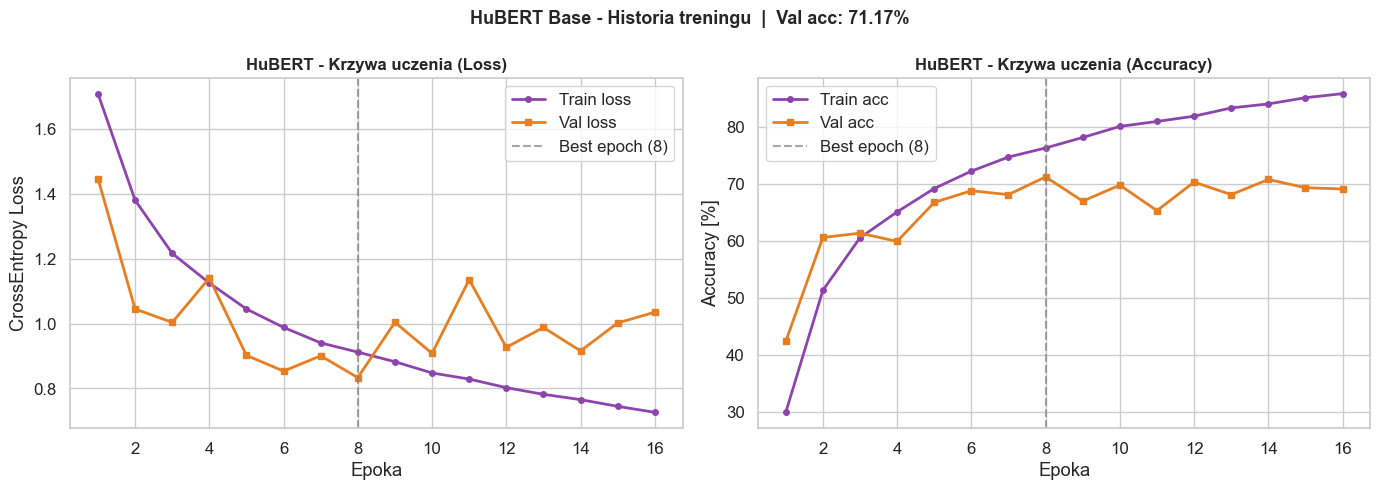

Wykres historii treningu zapisany.


In [120]:
hist_h = best_hubert_result['history']
eps_h = range(1, len(hist_h['train_loss']) + 1)
best_ep = best_hubert_result['best_epoch']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(eps_h, hist_h['train_loss'], 'o-', label='Train loss', color='#8e44ad', linewidth=2, markersize=4)
axes[0].plot(eps_h, hist_h['val_loss'], 's-', label='Val loss', color='#e67e22', linewidth=2, markersize=4)
axes[0].axvline(best_ep, color='gray', linestyle='--', alpha=0.7, label=f'Best epoch ({best_ep})')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('CrossEntropy Loss')
axes[0].set_title('HuBERT - Krzywa uczenia (Loss)', fontsize=12, fontweight='bold')
axes[0].legend()

axes[1].plot(eps_h, [a * 100 for a in hist_h['train_acc']], 'o-', label='Train acc', color='#8e44ad', linewidth=2, markersize=4)
axes[1].plot(eps_h, [a * 100 for a in hist_h['val_acc']], 's-', label='Val acc', color='#e67e22', linewidth=2, markersize=4)
axes[1].axvline(best_ep, color='gray', linestyle='--', alpha=0.7, label=f'Best epoch ({best_ep})')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Accuracy [%]')
axes[1].set_title('HuBERT - Krzywa uczenia (Accuracy)', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle(
    f'HuBERT Base - Historia treningu  |  Val acc: {best_hubert_result["val_acc"]*100:.2f}%',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'hubert_training_history.png', bbox_inches='tight', dpi=150)
plt.show()
print('Wykres historii treningu zapisany.')

### 5.6 Zapis modelu

In [121]:
torch.save({
    'model_state_dict': best_hubert_result['model_state'],
    'config': best_hubert_config,
    'val_acc': best_hubert_result['val_acc'],
    'class_names': CLASS_NAMES,
}, MODELS_DIR / 'hubert_model.pth')
print('hubert_model.pth zapisany.')

hubert_model.pth zapisany.
